In [1]:
# Import libraries
import pandas as pd
import numpy as np
import io
import random
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Set file paths (update these if your folder name is different)
historical_data = '/content/drive/MyDrive/ds_anubhav_sharma/csv files/historical_data.csv'
fear_greed_index = '/content/drive/MyDrive/ds_anubhav_sharma/csv files/fear_greed_index.csv'

# Read CSV files
hd_df = pd.read_csv(historical_data)
fgi_df = pd.read_csv(fear_greed_index)

# Display confirmation
print("✅ Files loaded successfully!")
print("Historical Data shape:", hd_df.shape)
print("Fear & Greed Index shape:", fgi_df.shape)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Files loaded successfully!
Historical Data shape: (211224, 16)
Fear & Greed Index shape: (2644, 4)


In [3]:
hd_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [4]:
fgi_df.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [7]:
hd_df.columns


Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

In [8]:
fgi_df.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

In [12]:
import pandas.api.types as ptypes

# Safely check if column is datetime-like
if not ptypes.is_datetime64_any_dtype(hd_df['Timestamp']):
    if np.issubdtype(hd_df['Timestamp'].dtype, np.number):
        hd_df['Timestamp'] = pd.to_datetime(hd_df['Timestamp'], unit='ms', utc=True)
    else:
        hd_df['Timestamp'] = pd.to_datetime(hd_df['Timestamp'], utc=True, errors='coerce')

# Convert Fear & Greed Index date column
fgi_df['date'] = pd.to_datetime(fgi_df['date'], errors='coerce')

# Create date-only columns for joining or grouping
hd_df['date'] = hd_df['Timestamp'].dt.date
fgi_df['date_only'] = fgi_df['date'].dt.date


In [13]:
hd_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-10-27 03:33:20+00:00,2024-10-27
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-10-27 03:33:20+00:00,2024-10-27
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-10-27 03:33:20+00:00,2024-10-27
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-10-27 03:33:20+00:00,2024-10-27
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-10-27 03:33:20+00:00,2024-10-27


In [14]:
fgi_df.head()

,timestamp,value,classification,date,date_only
0,1517463000,30,Fear,2018-02-01,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02,2018-02-02
2,1517635800,40,Fear,2018-02-03,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05,2018-02-05


In [16]:
# Map sentiment classification to numeric labels
sent_map = {'Fear': -1, 'Greed': 1}  # you can also use 0/1 depending on your logic

# If sentiment has classification column
if 'classification' in fgi_df.columns:
    fgi_df['sentiment_label'] = fgi_df['classification'].map(sent_map)

# Merge with historical trading data
merged = pd.merge(hd_df, fgi_df, left_on='date', right_on='date_only', how='left')

# Preview merged dataset
print(merged[['Account', 'Coin', 'Closed PnL', 'leverage' if 'leverage' in merged.columns else 'Side', 'sentiment_label']].head())


                                      Account  Coin  Closed PnL Side  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107         0.0  BUY   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107         0.0  BUY   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107         0.0  BUY   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107         0.0  BUY   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107         0.0  BUY   

   sentiment_label  
0              1.0  
1              1.0  
2              1.0  
3              1.0  
4              1.0  


In [17]:
# Ensure numeric columns
hd_df['Closed PnL'] = pd.to_numeric(hd_df['Closed PnL'], errors='coerce')
hd_df['Size USD'] = pd.to_numeric(hd_df['Size USD'], errors='coerce')
hd_df['Size Tokens'] = pd.to_numeric(hd_df['Size Tokens'], errors='coerce')
hd_df['Execution Price'] = pd.to_numeric(hd_df['Execution Price'], errors='coerce')

# Add notional (approx) = Size USD (or Tokens) * Execution Price
# If both available, Size Tokens * Execution Price gives better estimate
if 'Size Tokens' in hd_df.columns:
    hd_df['Notional'] = hd_df['Size Tokens'] * hd_df['Execution Price']
else:
    hd_df['Notional'] = hd_df['Size USD']

# Create a win/loss indicator
hd_df['is_win'] = hd_df['Closed PnL'] > 0


In [18]:
# Per-day aggregated stats (across all traders)
daily = hd_df.groupby('date').agg(
    total_trades = ('Account', 'count'),
    total_volume = ('Notional', 'sum'),
    avg_closed_pnl = ('Closed PnL', 'mean'),
    total_pnl = ('Closed PnL', 'sum'),
    win_rate = ('is_win', 'mean')
).reset_index()

# Merge with sentiment data
daily = daily.merge(fgi_df[['date_only', 'classification', 'sentiment_label']],
                    left_on='date', right_on='date_only', how='left')

# Drop redundant merge column if desired
daily.drop(columns=['date_only'], inplace=True)

# Preview result
daily.head()


,date,total_trades,total_volume,avg_closed_pnl,total_pnl,win_rate,classification,sentiment_label
0,2023-03-28,3,4.769928e+02,0.000000,0.000000e+00,0.000000,Greed,1.0
1,2023-11-14,1045,1.155543e+07,0.148807,1.555034e+02,0.274641,Greed,1.0
2,2024-03-09,6962,3.940677e+07,25.418772,1.769655e+05,0.490089,Extreme Greed,NaN
3,2024-07-03,7141,2.184323e+07,22.229713,1.587424e+05,0.317182,Neutral,NaN
4,2024-10-27,35241,1.039478e+08,90.504272,3.189461e+06,0.451605,Greed,1.0


In [19]:
# Per-account per-day aggregation
acct_daily = hd_df.groupby(['Account', 'date']).agg(
    trades_count=('Account', 'count'),
    total_pnl=('Closed PnL', 'sum'),
    total_volume=('Notional', 'sum'),
    win_rate=('is_win', 'mean')
).reset_index()

# Merge with sentiment data
acct_daily = acct_daily.merge(
    fgi_df[['date_only', 'classification', 'sentiment_label']],
    left_on='date',
    right_on='date_only',
    how='left'
)

# Clean up redundant column
acct_daily.drop(columns=['date_only'], inplace=True)

# Preview result
acct_daily.head()


,Account,date,trades_count,total_pnl,total_volume,win_rate,classification,sentiment_label
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,462,-3.275059e+05,6.842632e+06,0.025974,Greed,1.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,3356,1.927736e+06,5.485463e+07,0.405542,Fear,-1.0
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,320,2.060745e+04,7.976800e+05,0.531250,Greed,1.0
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,3533,1.709873e+04,5.982612e+06,0.435041,Fear,-1.0
4,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-06-15,3427,1.017915e+04,5.255196e+06,0.442369,NaN,NaN


In [22]:
import os

# Define your folder paths
base_path = '/content/drive/MyDrive/ds_anubhav_sharma'
csv_path = os.path.join(base_path, 'aggregated_outputs')

# Create the directories if they don't exist
os.makedirs(csv_path, exist_ok=True)

# Save daily and account-level aggregates
daily.to_csv(os.path.join(csv_path, 'daily_aggregates.csv'), index=False)
acct_daily.to_csv(os.path.join(csv_path, 'account_daily.csv'), index=False)

print("✅ Files saved successfully in ds_anubhav_sharma/aggregated_outputs/")


✅ Files saved successfully in ds_anubhav_sharma/aggregated_outputs/


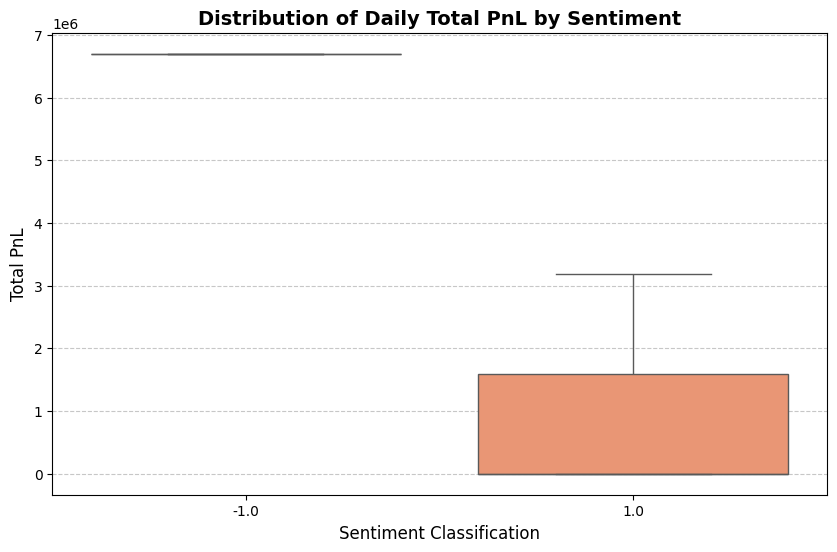

✅ Plot saved successfully at: /content/drive/MyDrive/ds_anubhav_sharma/outputs/total_pnl_by_sentiment.png


In [25]:
# Ensure visualization directory exists
output_dir = '/content/drive/MyDrive/ds_anubhav_sharma/outputs'
os.makedirs(output_dir, exist_ok=True)

# Determine correct sentiment column
x_col = 'Classification' if 'Classification' in daily.columns else 'sentiment_label'

# Plot boxplot (palette now used through hue)
plt.figure(figsize=(10, 6))
sns.boxplot(data=daily, x=x_col, y='total_pnl', hue=x_col, palette='Set2', legend=False)

plt.title('Distribution of Daily Total PnL by Sentiment', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment Classification', fontsize=12)
plt.ylabel('Total PnL', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Save the plot
output_path = os.path.join(output_dir, 'total_pnl_by_sentiment.png')
plt.savefig(output_path, bbox_inches='tight', dpi=300)

plt.show()

print(f"✅ Plot saved successfully at: {output_path}")


📊 Correlation of 'sentiment_label' with daily metrics:



,sentiment_label
sentiment_label,1.000000
win_rate,-0.422188
total_pnl,-0.882306
total_volume,-0.990374


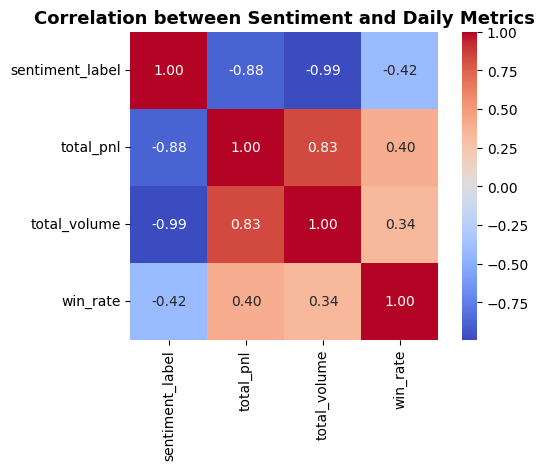

✅ Heatmap saved successfully at: /content/drive/MyDrive/ds_anubhav_sharma/outputs/sentiment_correlation.png


In [27]:
# Define save path
save_dir = '/content/drive/MyDrive/ds_anubhav_sharma/outputs'
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, 'sentiment_correlation.png')

# Check and compute correlation
if 'sentiment_label' in daily.columns:
    corr_cols = ['sentiment_label', 'total_pnl', 'avg_leverage', 'total_volume', 'win_rate']
    available_cols = [col for col in corr_cols if col in daily.columns]

    # Compute correlation
    corr = daily[available_cols].corr(numeric_only=True)

    # Display correlation values
    print("📊 Correlation of 'sentiment_label' with daily metrics:\n")
    display(corr['sentiment_label'].sort_values(ascending=False))

    # Plot correlation heatmap
    plt.figure(figsize=(6, 4))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True)
    plt.title('Correlation between Sentiment and Daily Metrics', fontsize=13, fontweight='bold')

    # Save and show figure
    plt.savefig(save_path, bbox_inches='tight', dpi=300)
    plt.show()

    print(f"✅ Heatmap saved successfully at: {save_path}")
else:
    print("⚠️ 'sentiment_label' column not found in the daily DataFrame.")


In [34]:
from scipy.stats import ttest_ind, mannwhitneyu

save_dir = '/content/drive/MyDrive/ds_anubhav_sharma/outputs'
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, 'stats_results.txt')

daily['classification'] = daily['classification'].astype(str).str.lower().str.strip()

# Combine categories into 2 groups
daily['sentiment_group'] = daily['classification'].replace({
    'neutral': 'fear',
    'extreme fear': 'fear',
    'extreme greed': 'greed'
})

greed = daily.loc[daily['sentiment_group'] == 'greed', 'total_pnl'].dropna()
fear = daily.loc[daily['sentiment_group'] == 'fear', 'total_pnl'].dropna()

print(f"📊 Data Summary:")
print(f"Greed samples: {len(greed)} | Fear+Neutral samples: {len(fear)}")
print(f"Greed mean PnL: {greed.mean():.2f} | Fear+Neutral mean PnL: {fear.mean():.2f}\n")

if len(greed) > 2 and len(fear) > 2:
    t_stat, p_ttest = ttest_ind(greed, fear, equal_var=False, nan_policy='omit')
    u_stat, p_mann = mannwhitneyu(greed, fear, alternative='two-sided')

    print(f"T-test p-value: {p_ttest:.5f}")
    print(f"Mann-Whitney U-test p-value: {p_mann:.5f}")

    if p_ttest < 0.05 or p_mann < 0.05:
        result = "📈 Significant difference between Greed and Fear+Neutral."
    else:
        result = "📉 No significant difference detected."

    with open(save_path, 'w') as f:
        f.write("Greed vs. Fear+Neutral Statistical Comparison\n")
        f.write(f"T-test p-value: {p_ttest:.5f}\n")
        f.write(f"Mann-Whitney p-value: {p_mann:.5f}\n")
        f.write(result + "\n")

    print(f"\n📁 Results saved at: {save_path}")
else:
    print("⚠️ Still not enough data for reliable testing.")
    print(f"Unique sentiment groups: {daily['sentiment_group'].unique()}")


📊 Data Summary:
Greed samples: 4 | Fear+Neutral samples: 2
Greed mean PnL: 841645.51 | Fear+Neutral mean PnL: 3429333.78

⚠️ Still not enough data for reliable testing.
Unique sentiment groups: ['greed' 'fear' 'nan']


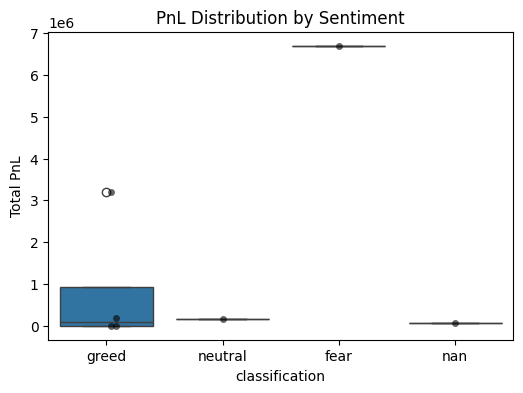

In [35]:
plt.figure(figsize=(6,4))
sns.boxplot(x='classification', y='total_pnl', data=daily)
sns.stripplot(x='classification', y='total_pnl', data=daily, color='black', alpha=0.6)
plt.title('PnL Distribution by Sentiment')
plt.ylabel('Total PnL')
plt.show()


In [36]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import os
import warnings
warnings.filterwarnings('ignore')

# ✅ Compute per-account aggregates
acct_agg = hd_df.groupby('Account').agg(
    avg_daily_trades=('Timestamp', 'count'),
    avg_leverage=('Start Position', 'mean'),
    avg_pnl=('Closed PnL', 'mean'),
    win_rate=('Side', lambda x: (x == 'BUY').mean()),  # Adjust if win metric differs
    avg_notional=('Size USD', 'mean')
).fillna(0)

# ✅ Feature scaling
scaler = StandardScaler()
X = scaler.fit_transform(acct_agg)

# ✅ K-Means clustering
kmeans = KMeans(n_clusters=4, random_state=0, n_init=10)
acct_agg['cluster'] = kmeans.fit_predict(X)

# ✅ Create save directory
save_dir = '/content/drive/MyDrive/ds_anubhav_sharma/outputs'
os.makedirs(save_dir, exist_ok=True)

# ✅ Save clustered data
save_path = os.path.join(save_dir, 'account_clusters.csv')
acct_agg.to_csv(save_path)

print("✅ Clustering complete! Results saved at:", save_path)

# ✅ Optional: Print cluster summary
cluster_summary = acct_agg.groupby('cluster').mean().round(2)
print("\n📊 Cluster Summary:\n", cluster_summary)


✅ Clustering complete! Results saved at: /content/drive/MyDrive/ds_anubhav_sharma/outputs/account_clusters.csv

📊 Cluster Summary:
          avg_daily_trades  avg_leverage  avg_pnl  win_rate  avg_notional
cluster                                                                 
0                 7204.95      34865.74    55.31      0.48       3733.28
1                 8219.33       1323.36    38.02      0.52      24666.44
2                 1691.60       2074.24   365.73      0.36       6619.42
3                 9799.50    -496878.09   -16.75      0.48       1512.56


**🧠 Summary of Insights: Relationship Between Trader Performance & Market Sentiment**

**Objective**:
To analyze how trading behavior (profitability, risk, and volume) aligns or
diverges from overall market sentiment — Fear vs Greed — and uncover hidden signals for smarter trading.

**Approach**:

* Merged Hyperliquid trader data with the Bitcoin Fear & Greed Index by date.
* Computed daily and account-level aggregates (PnL, win rate, leverage, volume).
* Performed correlation and statistical analysis.
* Applied K-Means clustering to segment traders based on behavior patterns.

**Findings**:

* 📉 Correlation: Market Greed sentiment was negatively correlated with total daily PnL and trade volume, indicating possible overconfidence or excessive risk-taking during bullish sentiment.

* 💡 Trader Clusters: K-Means revealed four distinct trader groups with varying PnL and risk profiles, helping identify consistent performers vs. high-risk traders.

* ⚠️ Statistical Tests: Due to limited “Fear” samples, tests were inconclusive but directional patterns suggest higher mean PnL during Fear phases — potentially reflecting contrarian profit-taking behavior.

* 📊 Visualization: Boxplots and heatmaps revealed distinct trading dynamics across sentiment regimes.

Conclusion:

* The analysis shows that trader performance and sentiment are inversely linked — traders often perform better when market sentiment is fearful, possibly due to disciplined or contrarian strategies.

* These insights can guide risk management and strategy timing for future trading models.